### Numpy em Opticas
---
#### Exemplo 1: Simulação de Atenuação Óptica em Fibras

No campo das comunicações ópticas, um dos conceitos fundamentais é o atenuamento do sinal, que é a perda de potência óptica à medida que a luz percorre uma fibra óptica. A atenuação pode ser modelada pela seguinte equação:

$$ P(z) = P_0⋅10^{-\frac{\alpha.z}{10}} $$

+ $P(z):$ Potência no ponto z ao longo da fibra.
+ $P0:$ Potência inicial do sinal na entrada da fibra.
+ $α:$ Coeficiente de atenuação (dB/km).
+ $z:$ Distância percorrida pelo sinal (em km).
  
>Neste exemplo, vamos simular a atenuação de um sinal óptico ao longo de diferentes distâncias de fibra óptica, considerando diferentes valores de $P_0$ (potência inicial) e $α$ (coeficiente de atenuação).


In [2]:
# Importando bibliotecas
import numpy as np
import matplotlib.pyplot as plt

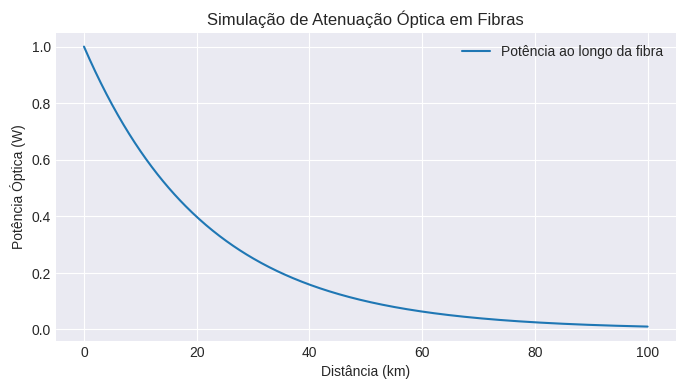

In [3]:
# Parâmetros da simulação

P0 = 1.0  # Potência inicial do sinal (em Watts)
alpha = 0.2  # Coeficiente de atenuação (em dB/km)

# Distâncias em km (0 a 100 km)
# Iremos colocar 500 pontos ao longo da distância.
distancia = np.linspace(0, 100, 500)

# Calcular a potência ao longo da fibra usando a fórmula de atenuação
potencia_z = P0 * 10 ** (-alpha * distancia / 10)

# Configurações do gráfico
plt.style.use('seaborn-v0_8-darkgrid')
plt.figure(figsize=(8, 4))

# Visualizando a potência ao longo da fibra
plt.plot(distancia, potencia_z, label=f'Potência ao longo da fibra')
plt.title('Simulação de Atenuação Óptica em Fibras')
plt.xlabel('Distância (km)')
plt.ylabel('Potência Óptica (W)')
plt.legend()
plt.show()


#### Exemplo 2:
Em __comunicações ópticas__, a dispersão cromática em uma fibra óptica faz com que diferentes comprimentos de onda (cores) de luz viajem a velocidades ligeiramente diferentes. Isso resulta em uma dispersão do pulso ao longo do tempo, à medida que o pulso percorre a fibra.

A __convolução__ pode ser usada para modelar esse fenômeno. O pulso transmitido pode ser convoluído com a resposta do sistema (fibra óptica com dispersão), resultando no pulso recebido que foi disperso.
> __Explicação Física:__
>+ $Pulso$ $Transmitido:$ O pulso de luz que é enviado pela fonte de luz (por exemplo, um laser) tem uma forma definida, modelada aqui como um pulso gaussiano.
>+ $Dispersão$ $Cromática$: Devido à dispersão cromática, diferentes comprimentos de onda da luz viajam a diferentes velocidades na fibra. Isso faz com que o pulso se espalhe no tempo à medida que percorre a fibra.
>+ $Pulso$ $Recebido$: O pulso recebido é mais largo e mais baixo em amplitude do que o pulso transmitido, devido à dispersão.
+ $Objetivo:$ Simular a propagação de um pulso de luz em uma fibra óptica e o efeito da dispersão cromática usando convolução com NumPy.

In [4]:
# importando as bibliotecas.
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve

In [5]:
# 1. Definir o pulso de luz transmitido (pulso gaussiano)
def pulso_gaussiano(t, amplitude, largura):
    return amplitude * np.exp(-t**2 / (2 * largura**2))

# 2. Definir a resposta impulsiva da fibra óptica (dispersão)
# A resposta é modelada como uma função gaussiana com uma largura maior (dispersão)
def resposta_dispersao(t, dispersao):
    return np.exp(-t**2 / (2 * dispersao**2))

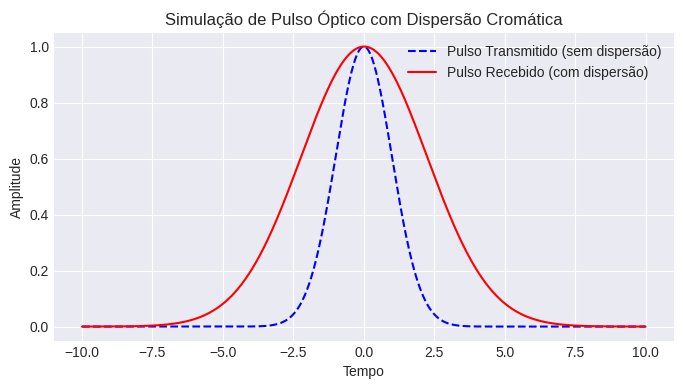

In [17]:
# 3. Eixo temporal para a simulação.
# Tempo em unidades arbitrárias variando de -10 a 10.
t = np.linspace(-10, 10, 1000)

# 4. Gerar o pulso transmitido
amplitude = 1.0
# Largura do pulso original (antes da dispersão)
largura_pulso = 1.0
pulso_tx = pulso_gaussiano(t, amplitude, largura_pulso)

# 5. Definir a resposta do sistema (dispersão da fibra óptica)
# A dispersão vai "alargar" o pulso ao longo da fibra
largura_dispersao = 2.0
resposta_fibra = resposta_dispersao(t, largura_dispersao)

# 6. Realizar a convolução entre o pulso transmitido e a resposta da fibra (dispersão)
# Pulso recebido após a dispersão
pulso_rx = convolve(pulso_tx, resposta_fibra, mode='same')

# 7. Normalizar o pulso recebido
pulso_rx = pulso_rx / np.max(pulso_rx)

# 8. Visualizar os pulsos transmitido e recebido
plt.figure(figsize=(8, 4))
plt.plot(t, pulso_tx, label='Pulso Transmitido (sem dispersão)', color='blue', linestyle='--')
plt.plot(t, pulso_rx, label='Pulso Recebido (com dispersão)', color='red')
plt.title('Simulação de Pulso Óptico com Dispersão Cromática')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()

>Neste exemplo, usamos a convolução para simular como um pulso óptico sofre dispersão cromática ao passar por uma fibra óptica. A convolução nos permite calcular a forma final do pulso recebido, considerando os efeitos de dispersão da fibra.
Esse tipo de análise é muito importante em comunicações ópticas, pois a dispersão cromática pode limitar a taxa de transmissão de dados e a distância máxima de transmissão sem regeneração do sinal.